In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu


# Get the current working directory
current_directory = os.getcwd()
# If required go to repository root
if os.path.split(current_directory)[1] != 'PAM_Parametrization':
    # Go up two levels
    parent_directory = os.path.dirname(os.path.dirname(current_directory))
    # Change the directory to the parent directory
    os.chdir(parent_directory)
    
from PAModelpy.utils import set_up_pam
from Scripts.pam_generation import setup_ecoli_pam as set_up_ecoli_pam_curated
from Modules.utils.sector_config_functions import change_translational_sector_with_config_dict

from Modules.utils.pamparametrizer_analysis import (get_results_from_simulations,
                                                   calculate_error_for_reactions, calculate_r_squared_for_reaction,
                                                   calculate_difference_simulation_experiment)
from Modules.utils.pam_generation import create_pamodel_from_diagnostics_file


# from Modules.utils import calculate_r_squared_for_reaction
# from Scripts.Visualization.PAMparametrizer_progress_cleaned_figure import run_simulations
N_ALT_MODELS = 10

ECOLI_PHENOTYPE_DATA_PATH = os.path.join('Data', 'Ecoli_phenotypes')

MODEL_FILE_PATH = os.path.join('Models', 'iML1515.xml')

PARAM_FILE_OLD = os.path.join('Results', '1_preprocessing','proteinAllocationModel_iML1515_EnzymaticData_241209.xlsx')
PARAM_FILE_SCALED = os.path.join('Results', '2_parametrization','proteinAllocationModel_iML1515_EnzymaticData_241209_multi.xlsx')

BEST_INDIV_RESULT_FILES = [os.path.join('Results','2_parametrization','diagnostics',
                                     f'pam_parametrizer_diagnostics_{i}.xlsx') for i in range(1,N_ALT_MODELS+1)]

Loading PAModelpy modules version 0.0.4.6
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-06


# 1. Load reference data

In [2]:
# load flux data glucose
flux_df = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'Ecoli_phenotypes_py.xls'),
                       sheet_name = 'Fluxes',
                            engine='openpyxl',
                            index_col=1)
flux_df.head()

,Description,Reaction_position,Rijsewijk_2011,Nanchen_2006_1,Nanchen_2006_2,Nanchen_2006_3,Nanchen_2006_4
Reaction_ID,,,,,,,
EX_glc__D_e,Glucose uptake,2805,8.26,1.670000,2.800000,4.220000,5.650000
BIOMASS_Ec_iML1515_core_75p37M,Growth rate,2712,0.61,0.085000,0.187000,0.286000,0.399000
EX_ac_e_f,Acetate secretion,34,4.89,0.000000,0.000000,0.000000,0.000000
PGI_f,Upper EMP (pgi),102,5.81,1.204014,1.565375,2.653420,3.625868
G6PDH2r_f,Upper PPP (zwf),658,2.29,0.461701,1.263167,1.639352,2.058864


# 2. Setup the *Escherichia coli* iML1515 model with new parameters

In [3]:
#setup the model
ecoli_pam_wt = set_up_pam(PARAM_FILE_OLD, 
                          model = MODEL_FILE_PATH, 
                          sensitivity=False) # not curation for reference
ecoli_pam_curated = set_up_ecoli_pam_curated(
    pam_data_file_path = os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_py.xls'),
    sensitivity = False) # curated for reference

pam = set_up_pam(PARAM_FILE_SCALED, 
                 model = MODEL_FILE_PATH,
                 sensitivity = False)
pam.change_reaction_bounds('EX_glc__D_e', lower_bound=0)

new_ecoli_pams = {alt+1: create_pamodel_from_diagnostics_file(file,
                                          pam.copy(copy_with_pickle=True)) for alt, file in enumerate(BEST_INDIV_RESULT_FILES)}

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector



/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:245: UserWarning: Molar mass for E332 is invalid: 0.0
  warnings.warn(f"Molar mass for {enz.id} is invalid: {molmass}")


Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedProteinSector

Done with setting up the proteome allocation model iML1515

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515



# 3. Check internal flux distribution (glucose as C source)

## 3.1 Run the simulations and calculate the errors

In [4]:
# Get the data from the MFA studies of Rijsewijk et al (2011) and Nanchen et al. (2006)
new_indices = []
for i, row in flux_df.iterrows():
    if isinstance(row.name, str):
        if row.name[-2:] == '_b':
            new_indices.append(row.name[:-2])
            fluxes_to_simulate.loc[row.name]= -row
        if row.name[-2:] == '_f':
            new_indices.append(row.name[:-2])
        else: 
            new_indices.append(row.name)
    else:
        new_indices.append(row.name)
            
flux_df.index = new_indices
flux_df_data = flux_df.drop(['Description', 'Reaction_position'], axis =1)


fluxes_to_save = None
flux_information = {}
validation_df = pd.DataFrame(columns = new_indices)
studies = []
substrate_uptake = []
for study, fluxes in flux_df_data.items():
    studies += [study]
    substrate_uptake += [-fluxes.loc['EX_glc__D_e']]
    flux_information[study] = fluxes.to_dict()
    validation_df = pd.concat([validation_df,fluxes.to_frame().T], ignore_index =True)
    
    #store the names of the fluxes to save
    if fluxes_to_save is None:
        fluxes_to_save = list(fluxes.index)


In [5]:
kwargs = {'substrate_ids': ['EX_glc__D_e'], 
          'substrate_rates': [substrate_uptake],
          'fluxes_to_save' : fluxes_to_save}
# for each study, run simulations
fluxes_curated = get_results_from_simulations(ecoli_pam_curated, **kwargs)['fluxes']
print('\n')
fluxes_wt = get_results_from_simulations(ecoli_pam_wt,**kwargs)['fluxes']
print('\n')
# fluxes_new = run_simulations(ecoli_pam_new, **kwargs)

for alt, pam in new_ecoli_pams.items():
    pam.change_reaction_bounds('EX_glc__D_e', 0, 1e3)
    new_ecoli_pams[alt] = pam

fluxes_new_dict = {alt: get_results_from_simulations(pam, **kwargs)['fluxes'] for alt, pam in new_ecoli_pams.items()}

Running simulations with -8.26 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -1.67 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -2.8 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.22 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -5.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system


Running simulations with -8.26 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -1.67 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -2.8 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.22 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -5.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system


Running simulations with -8.26 mmol/g_cdw/h of substrate (EX_glc__D_

In [6]:
#calculate R^2 value between simulations and experiments
error_curated = calculate_error_for_reactions(validation_df,
                                                 fluxes_curated,
                                                 fluxes_to_save[1:])
print('R^2 values for the model with published parameter set :', np.nanmean(error_curated))

error_wt = calculate_error_for_reactions(validation_df,
                                                 fluxes_wt,
                                                 fluxes_to_save[1:])
print('R^2 values for the model with parameters from GotEnzymes: ', np.nanmean(error_wt))


error_new_dict = {alt: calculate_error_for_reactions(validation_df,
                                                  fluxes,
                                                  fluxes_to_save[1:]) for alt, fluxes in fluxes_new_dict.items()}
for alt, error_list in error_new_dict.items():
    print(f'R^2 values for alternative model {alt} with the optimized parameters: ', np.nanmean(error_list))




R^2 values for the model with published parameter set : -73.21472692605792
R^2 values for the model with parameters from GotEnzymes:  -2.5392701342237785
R^2 values for alternative model 1 with the optimized parameters:  -0.48625128736827306
R^2 values for alternative model 2 with the optimized parameters:  -6.050549055051718
R^2 values for alternative model 3 with the optimized parameters:  -6.537073499743367
R^2 values for alternative model 4 with the optimized parameters:  -0.21630431401390204
R^2 values for alternative model 5 with the optimized parameters:  -1.4796940250898742
R^2 values for alternative model 6 with the optimized parameters:  -0.2368577866719388
R^2 values for alternative model 7 with the optimized parameters:  -1.0731838801207554
R^2 values for alternative model 8 with the optimized parameters:  -0.8041286578754093
R^2 values for alternative model 9 with the optimized parameters:  -4.232782823374662
R^2 values for alternative model 10 with the optimized parameter

## 3.2 Visualize the simulation results for the different models

In [7]:
# validation_df_1.index = validation_df.index.str.split(', ')
validation_df_1 = validation_df.T.reset_index()
validation_df_1['index'] = validation_df_1['index'].str.split(', ')
validation_df_1 = validation_df_1.explode('index').set_index('index').T
validation_df_1
# validation_df = validation_df.explode()

index,EX_glc__D_e,BIOMASS_Ec_iML1515_core_75p37M,EX_ac_e,PGI,G6PDH2r,EDA,CS,ICL,PPC,ME1,ME2
0,8.26,0.610,4.89,5.810000,2.290000,0.765000,2.245000,0.000000,2.780000,0.530000,0.530000
1,1.67,0.085,0.00,1.204014,0.461701,0.113477,2.036011,0.963408,0.511215,0.003525,0.003525
2,2.80,0.187,0.00,1.565375,1.263167,0.294722,2.879840,1.322975,0.834799,0.410990,0.410990
3,4.22,0.286,0.00,2.653420,1.639352,0.378028,4.348612,0.541035,1.674173,0.670016,0.670016
4,5.65,0.399,0.00,3.625868,2.058864,0.409410,5.481990,0.000000,2.586144,0.458187,0.458187


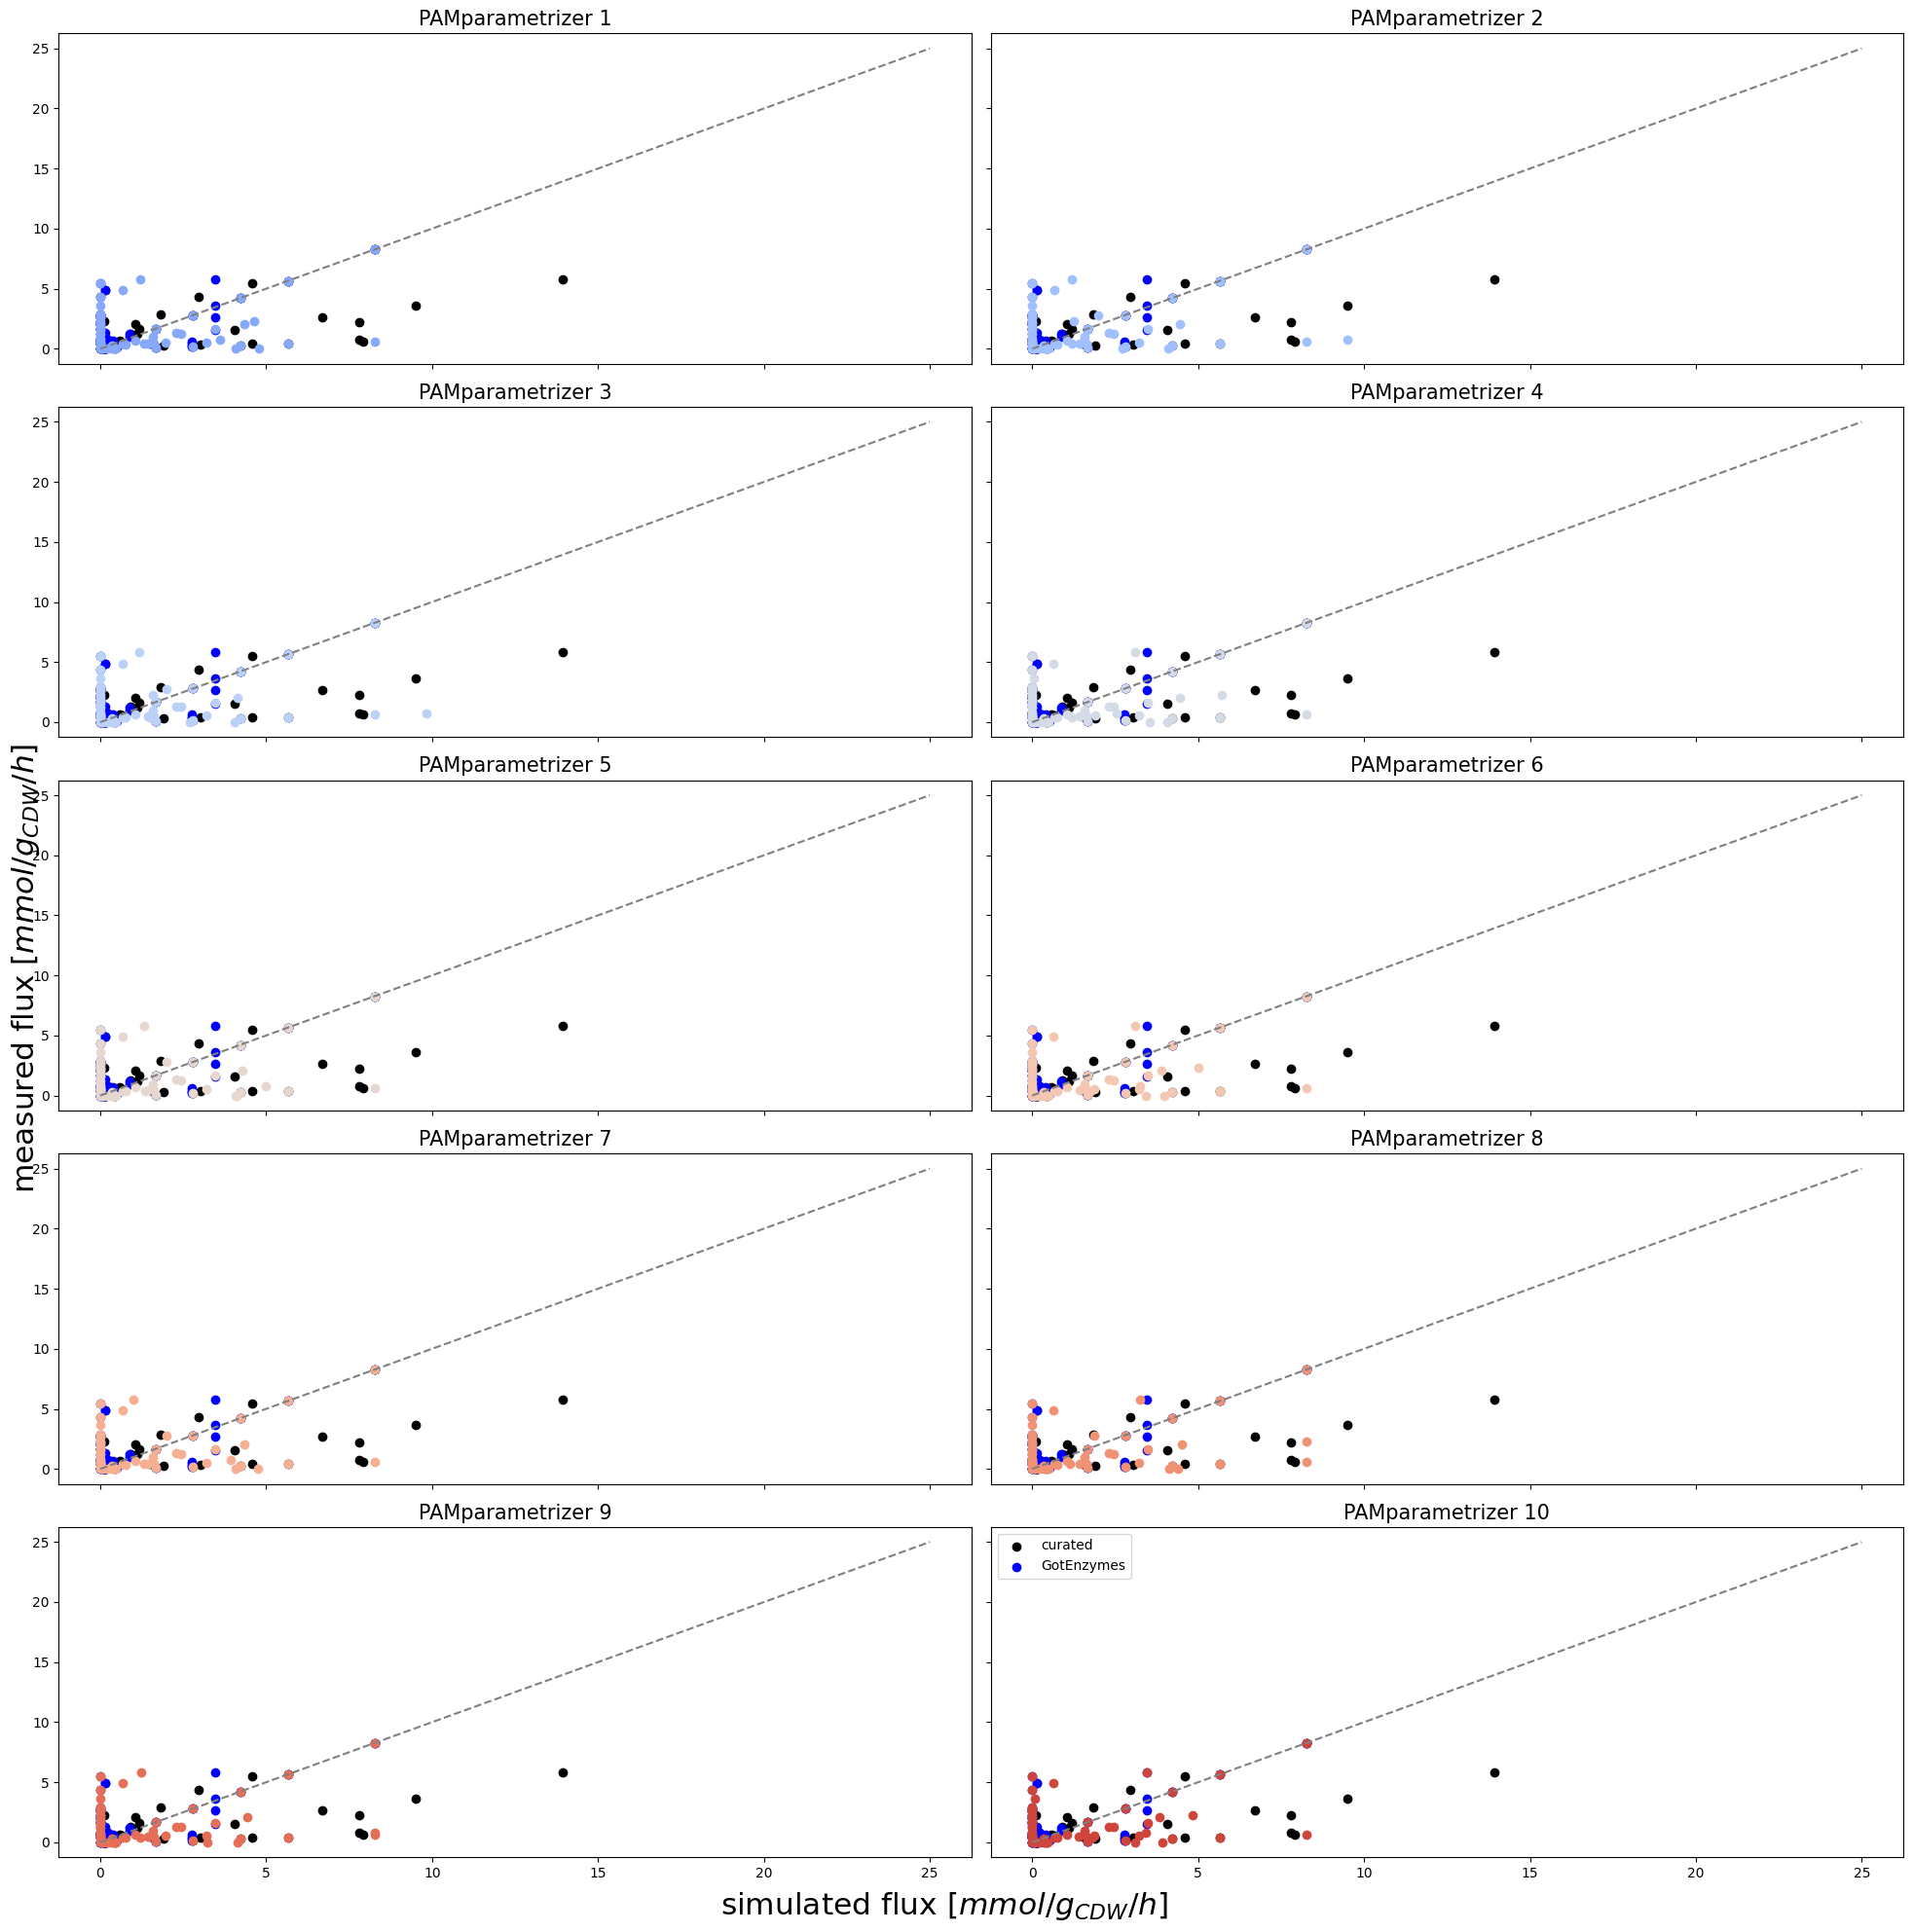

In [8]:
models = ['GotEnzymes','Curated'] + [f'PAMparametrizer {alt}' for alt in range(1,N_ALT_MODELS+1)]
model_colors = sns.color_palette("coolwarm", n_colors=len(models))
cmap = dict(zip(models, model_colors))
fontsize=15

fig, axs = plt.subplots(nrows = int(len(fluxes_new_dict)/2), ncols = 2, sharey='row', sharex='col', figsize = (20,20))
axs = axs.flatten()

for alt, fluxes_new in fluxes_new_dict.items():
    ax = axs[alt-1]
    curated = []
    wt = []
    new = []
    validation = []
    for i in range(len(fluxes_curated)):
        curated += [abs(flx) for flx in fluxes_curated.iloc[i].to_list()[1:-1]]
        if i<len(fluxes_wt):
            wt += [abs(flx) for flx in fluxes_wt.iloc[i].to_list()[1:-1]]
        else:
            wt += [0]*len(fluxes_curated.iloc[i].to_list()[1:-1])
        if i<len(fluxes_new):
            new += [abs(flx) for flx in fluxes_new.iloc[i].to_list()[1:-1]]
        else:
            new += [0]*len(fluxes_curated.iloc[i].to_list()[1:-1])
        validation += validation_df_1.iloc[i].abs().to_list()
    
    ax.plot([0,25], [0,25], linestyle = 'dashed', color='grey')
    ax.scatter(curated, validation, label = 'curated', color = 'black')
    ax.scatter(wt, validation, label = 'GotEnzymes', color ='blue')
    ax.scatter(new, validation, color = cmap[f'PAMparametrizer {alt}'])#, label = f'PAMparametrizer {alt}'
    ax.set_title(f'PAMparametrizer {alt}', fontsize = fontsize)

fig.supxlabel('simulated flux [$mmol/g_{CDW}/h$]', fontsize = fontsize*1.5)
fig.supylabel('measured flux [$mmol/g_{CDW}/h$]', fontsize = fontsize*1.5)
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
def plot_significant_annotation(ax, column, sign, compare_df, dodge_factor):
        # Add annotation for significance
        x1, x2 = 1, column
        start = compare_df.Difference.quantile(0.865) +0.65
        y, h = compare_df.Difference.quantile(0.865)+ dodge_factor, 0.75  # Dynamically adjust y position
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, start], lw=1.5, color='k')
        ax.text((x1 + x2) * 0.5, y + h*0.6, sign, ha='center', va='bottom', fontsize=fontsize, color='k')

alternative 1: U-statistic = 1605.5, p-value = 0.007175620967477165
alternative 2: U-statistic = 1578.5, p-value = 0.011850347834783646
alternative 3: U-statistic = 1580.5, p-value = 0.011430815646053671
alternative 4: U-statistic = 1634.5, p-value = 0.004046886919919493
alternative 5: U-statistic = 1578.0, p-value = 0.011957083960646119
alternative 6: U-statistic = 1627.5, p-value = 0.004660127666088163
alternative 7: U-statistic = 1578.0, p-value = 0.011957083960646119
alternative 8: U-statistic = 1591.5, p-value = 0.009346506483486613
alternative 9: U-statistic = 1591.0, p-value = 0.009428309566110855
alternative 10: U-statistic = 1632.5, p-value = 0.004215046515403033


/tmp/ipykernel_954848/3933430649.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap, showfliers=False)
/tmp/ipykernel_954848/3933430649.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)


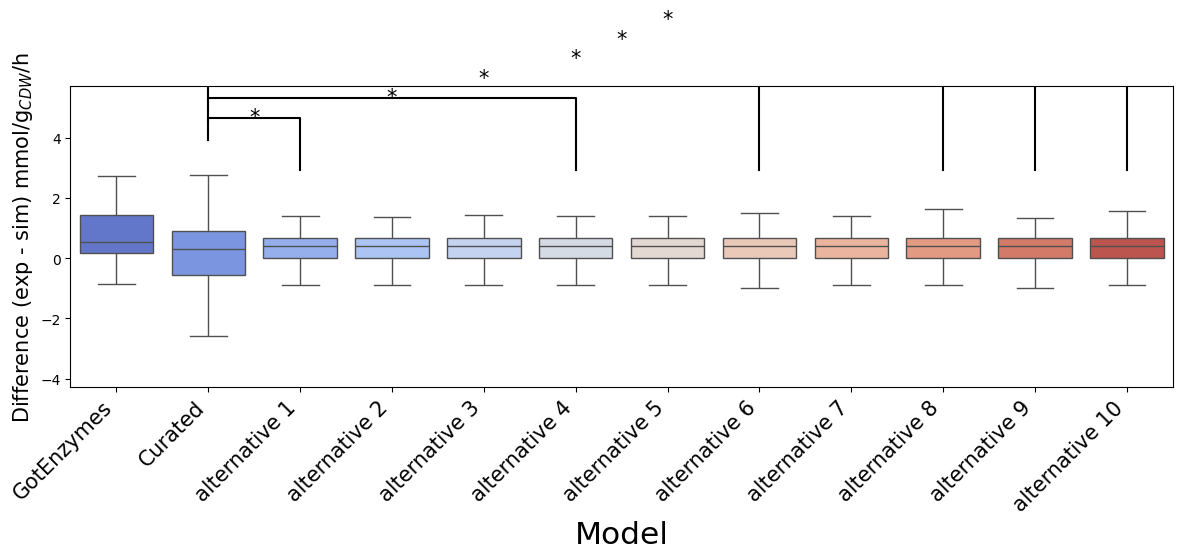

In [10]:
fontsize = 15
models = ['GotEnzymes', 'Curated'] + [f'alternative {alt}' for alt in error_new_dict.keys()]
model_colors = sns.color_palette("coolwarm", n_colors=len(models))
cmap = dict(zip(models, model_colors))

# Prepare the figure
fig, ax = plt.subplots(figsize=(12, 6))

# Combine data into a DataFrame
all_differences = pd.DataFrame()
curated_differences = None  # Placeholder for Curated errors
num_significant = 0

for col, (model, sub_df) in enumerate(zip(models, [fluxes_wt, fluxes_curated] + list(fluxes_new_dict.values()))):
    differences = []
    for _, row in sub_df.iterrows():
        substrate_id = row['substrate_id']
        difference = calculate_difference_simulation_experiment(
            validation_df_1, row, fluxes_to_save[1:], substrate_id)
        differences += difference

    temp_df = pd.DataFrame({'Model': [model] * len(differences), 'Difference': differences})
    
    # Store curated differences for comparison
    if model == 'GotEnzymes':
        curated_differences = differences
        curated_diff_df = temp_df[temp_df.Model == 'GotEnzymes']
    elif 'PAMparametrizer' in model or 'alternative' in model:
        # Statistical test
        stat, p = mannwhitneyu(curated_differences, differences, alternative='greater')
        print(f"{model}: U-statistic = {stat}, p-value = {p}")
#         if p < 0.075:
#             sign = '*'
#         if p < 0.05:
#             sign = '**'
        if p < 0.01:
            sign = '*'
#         if p < 0.075:
            num_significant += 1
            plot_significant_annotation(ax, col, sign, curated_diff_df, 1+num_significant*0.65)

    # Append to the main DataFrame
    all_differences = pd.concat([all_differences, temp_df], ignore_index=True)

# Boxplot or Violin Plot
sns.boxplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap, showfliers=False)

# Adjust y-axis to focus on bulk data and add space for annotations
ax.set_ylim([all_differences['Difference'].quantile(0.05)-3, all_differences['Difference'].quantile(0.96)+3])

# Set labels and title
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)
ax.set_xlabel('Model', fontsize=fontsize * 1.5)
ax.set_ylabel(r'Difference (exp - sim) mmol/$\text{g}_{CDW}$/h', fontsize=fontsize)

plt.tight_layout()
# plt.show()
plt.savefig('Results/3_analysis/multiple_csources_error_boxplot.png')

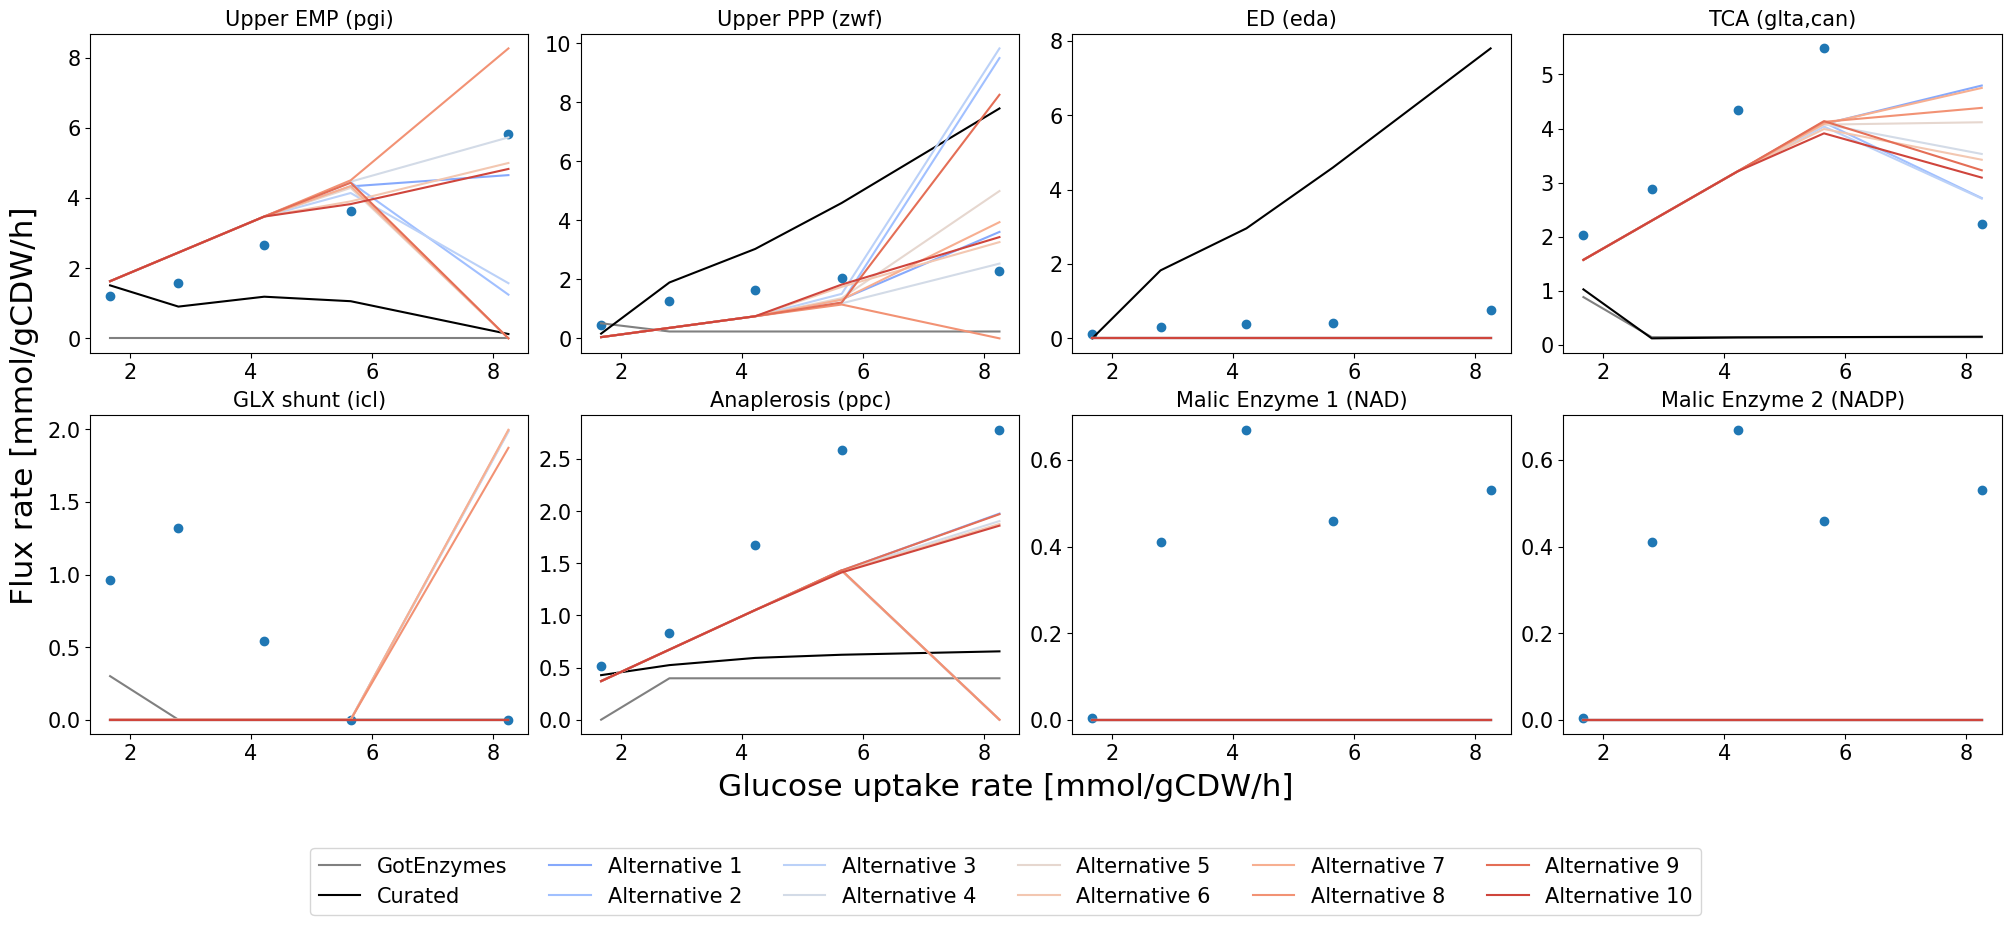

<Figure size 640x480 with 0 Axes>

In [42]:
# visualize per flux
substrate_ids_cur = fluxes_curated.substrate_id
substrate_ids = fluxes_new_dict[1].substrate_id

# visualize per flux
fluxes_to_plot = fluxes_to_save[3:]
num_fluxes_on_row = int(np.ceil(len(fluxes_to_plot)/2))
fig, axs = plt.subplots(ncols = num_fluxes_on_row, nrows = 2, figsize = [20,8], layout='constrained')
axs = axs.flatten()

# upper_fig_reactions = [rxn for rxn in fluxes_to_save[:5] if rxn != 'EDA'] #EDA is not in core model
# lower_fig_reactions = [rxn for rxn in fluxes_to_save[5:] if rxn != 'EDA']
upper_fig_reactions = [rxn for rxn in fluxes_to_plot[:num_fluxes_on_row]] #EDA is not in core model
lower_fig_reactions = [rxn for rxn in fluxes_to_save[num_fluxes_on_row:]]

fluxes_curated = fluxes_curated.sort_values('substrate')
fluxes_wt = fluxes_wt.sort_values('substrate')
for alt, fluxes in fluxes_new_dict.items():
    fluxes_new_dict[alt] = fluxes.sort_values('substrate')
substrate_rates = [abs(f) for f in fluxes_curated['substrate']]

for i, rxn in enumerate(fluxes_to_plot):
    validation = validation_df[rxn]
    axs[i].scatter(validation_df['EX_glc__D_e'], validation_df[rxn])    
    axs[i].plot(substrate_rates, [abs(f) for f in fluxes_wt[rxn]],label = 'GotEnzymes', color = 'grey')
    axs[i].plot(substrate_rates, [abs(f) for f in fluxes_curated[rxn]], label = 'Curated', color = 'black')
    for alt, fluxes in fluxes_new_dict.items():
        axs[i].plot(substrate_rates, [abs(f) for f in fluxes[rxn]], label = f'Alternative {alt}', 
                          color = cmap[f'alternative {alt}'])    
    axs[i].set_title(flux_df.Description.loc[rxn], fontsize = fontsize)
#     axs[i].set_yticks(fontsize = fontsize)
#     axs[i].set_xticks(fontsize = fontsize)
    axs[i].xaxis.set_tick_params(labelsize=fontsize)
    axs[i].yaxis.set_tick_params(labelsize=fontsize)

    
handles, labels = axs[i].get_legend_handles_labels()    
fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor=(0.5, -0.15),ncols = 6, fontsize= fontsize)

fig.supylabel('Flux rate [mmol/gCDW/h]', fontsize = fontsize*1.5)
fig.supxlabel('Glucose uptake rate [mmol/gCDW/h]', fontsize = fontsize*1.5)

    
# plt.legend(loc = 'lower center')
# plt.tight_layout()
plt.show()
plt.savefig('Results/3_analysis/flux_comparison_glucose_intracellular.png')